In [18]:
import numpy as np
import pandas as pd
import re

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

In [3]:
reviewes  = pd.read_csv("amazon_reviews_v1.csv.csv")

In [8]:
reviewes.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [11]:
reviewes = reviewes[reviewes['Score'] != 3].copy()

In [12]:
reviewes['Sentiment'] = reviewes['Score'].apply(lambda x: 1 if x > 3 else 0)

In [13]:
print(reviewes['Sentiment'].value_counts())

Sentiment
1    443777
0     82037
Name: count, dtype: int64


In [19]:
def cleanText(text):
    text = re.sub(r'<br />', ' ', text) # Remove HTML line breaks
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    return text

reviewes['CleanedText'] = reviewes['Text'].apply(cleanText)

In [20]:
reviewes['CleanedText'].head()

0    I have bought several of the Vitality canned d...
1    Product arrived labeled as Jumbo Salted Peanut...
2    This is a confection that has been around a fe...
3    If you are looking for the secret ingredient i...
4    Great taffy at a great price  There was a wide...
Name: CleanedText, dtype: object

Text(0.5, 1.0, 'Distribution of Positive (1) vs Negative (0) Reviews')

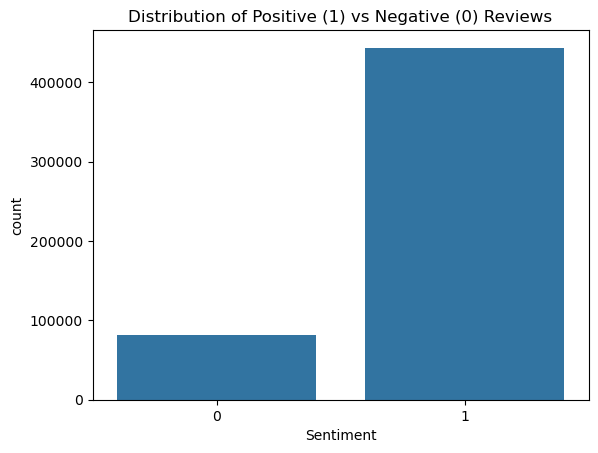

In [21]:
sns.countplot(x=reviewes['Sentiment'], data=reviewes)
plt.title('Distribution of Positive (1) vs Negative (0) Reviews')

In [24]:
positive_reviews = reviewes[reviewes['Sentiment'] == 1]
negative_reviews = reviewes[reviewes['Sentiment'] == 0]

In [25]:
downed_sample = positive_reviews.sample(n=len(negative_reviews), random_state=42)

In [26]:
balanced_reviews = pd.concat([downed_sample, negative_reviews])

In [27]:
balanced_reviews = balanced_reviews.sample(frac=1, random_state=42).reset_index(drop=True)

In [29]:
print(balanced_reviews['Sentiment'].value_counts())

Sentiment
1    82037
0    82037
Name: count, dtype: int64


In [30]:
reviewes['CleanedText'] = reviewes['Text'].apply(cleanText)

In [31]:
print(reviewes['Text'])

0         I have bought several of the Vitality canned d...
1         Product arrived labeled as Jumbo Salted Peanut...
2         This is a confection that has been around a fe...
3         If you are looking for the secret ingredient i...
4         Great taffy at a great price.  There was a wid...
                                ...                        
568449    Great for sesame chicken..this is a good if no...
568450    I'm disappointed with the flavor. The chocolat...
568451    These stars are small, so you can give 10-15 o...
568452    These are the BEST treats for training and rew...
568453    I am very satisfied ,product is as advertised,...
Name: Text, Length: 525814, dtype: object


<Axes: xlabel='Sentiment', ylabel='count'>

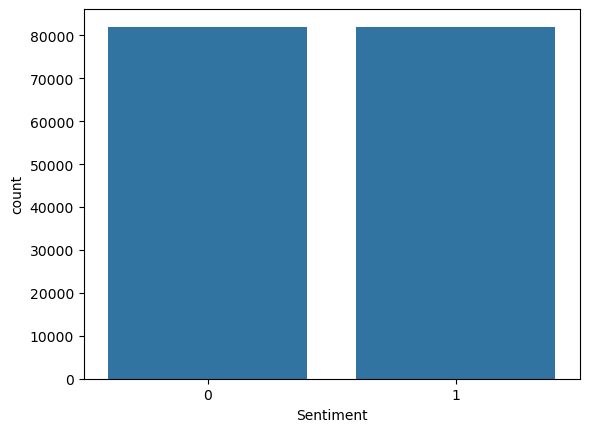

In [34]:
sns.countplot(x=balanced_reviews['Sentiment'], data=balanced_reviews)

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
X = balanced_reviews['CleanedText']
y = balanced_reviews['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=balanced_reviews['Sentiment'],random_state=42)

In [39]:
vectorizer = TfidfVectorizer(max_features=5000)

In [40]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [41]:
X_test_tfidf = vectorizer.transform(X_test)

In [42]:
print(f"Data shape after vectorizaton: {X_train_tfidf.shape}")

Data shape after vectorizaton: (131259, 5000)


In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
model = LogisticRegression(max_iter=1000)

In [45]:
model.fit(X_train_tfidf, y_train)
print("Model Training Completed!")

Model Training Completed!


In [46]:
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score

In [47]:
y_pred = model.predict(X_test_tfidf)

In [48]:
print("--------Classification Report------------")
print(classification_report(y_test, y_pred))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}")

--------Classification Report------------
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     16408
           1       0.90      0.89      0.90     16407

    accuracy                           0.90     32815
   macro avg       0.90      0.90      0.90     32815
weighted avg       0.90      0.90      0.90     32815

Overall Accuracy: 0.90


In [49]:
import joblib

In [50]:
joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("Model and vectorizer saved as .pkl files!")

Model and vectorizer saved as .pkl files!
